In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from llm import explain_anomalies, generate_marketing_strategies
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage

In [2]:
# Run this once to install the OpenAI SDK, then you can comment it out
!pip install openai

In [3]:
# Configure OpenAI API key securely using environment variables.
import os
from dotenv import load_dotenv
load_dotenv()


True

In [4]:
# Run the ingestion pipeline — cleans and merges all CSVs in ./data/raw/
# and returns a single clean DataFrame ready for analysis.
# Make sure pipeline.py is in the same folder as this notebook.
from pipeline import run_pipeline

client_data = run_pipeline()
client_data.head()

00:37:01 | INFO     | =======================================================
00:37:01 | INFO     | PIPELINE START — run_id=20260615_003701
00:37:01 | INFO     | =======================================================
00:37:01 | INFO     | Found 3 CSV file(s) in './data/raw'
00:37:01 | INFO     |   [OK]   'customers_feb.csv' — 51 rows, 5 cols
00:37:01 | INFO     |   [OK]   'customers_jan.csv' — 50 rows, 5 cols
00:37:01 | INFO     |   [OK]   'customers_mar.csv' — 71 rows, 5 cols
00:37:01 | INFO     | Processing 'customers_feb.csv' ...
00:37:01 | INFO     |   [customers_feb.csv] Schema OK
00:37:01 | WARNING  |   [customers_feb.csv] 'Edad': 1 value(s) could not be parsed as numeric and were set to NaN
00:37:01 | WARNING  |   [customers_feb.csv] 'Puntuación de Gasto (1-100)': 1 value(s) could not be parsed as numeric and were set to NaN
00:37:01 | WARNING  |   [customers_feb.csv] Dropped 1 duplicate CustomerID row(s)
00:37:01 | INFO     |   [customers_feb.csv] Imputed 1 missing 'Edad' valu

,CustomerID,Edad,Ingresos Anuales (k$),Puntuación de Gasto (1-100),Categoría de Producto Favorito
0,51,32.0,41,28.0,Home
1,52,33.0,42,35.0,Electronics
2,53,34.0,43,52.0,Books
3,54,35.0,43,51.0,Food
4,55,36.0,44,55.0,Home


In [5]:
client_data.isnull().sum()

CustomerID                        0
Edad                              0
Ingresos Anuales (k$)             0
Puntuación de Gasto (1-100)       0
Categoría de Producto Favorito    0
dtype: int64

In [6]:
print(f'SHAPE:\n{client_data.shape}\n')

print('INFO:')
client_data.info()

print('\nDESCRIBE:')
print(client_data.describe())

SHAPE:
(168, 5)

INFO:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168 entries, 0 to 167
Data columns (total 5 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   CustomerID                      168 non-null    int64  
 1   Edad                            168 non-null    float64
 2   Ingresos Anuales (k$)           168 non-null    int64  
 3   Puntuación de Gasto (1-100)     168 non-null    float64
 4   Categoría de Producto Favorito  168 non-null    object 
dtypes: float64(2), int64(2), object(1)
memory usage: 6.7+ KB

DESCRIBE:
       CustomerID        Edad  Ingresos Anuales (k$)  \
count  168.000000  168.000000             168.000000   
mean    84.500000   35.738095              55.142857   
std     48.641546   10.277141              23.135965   
min      1.000000   18.000000              15.000000   
25%     42.750000   29.000000              38.750000   
50%     84.500000   34.500000        

In [7]:
# Normalize data
scaler = MinMaxScaler()
normalized_d = scaler.fit_transform(client_data[["Edad", "Ingresos Anuales (k$)", "Puntuación de Gasto (1-100)"]])
normalized_d[:5]


array([[0.2745098 , 0.26804124, 0.26041667],
       [0.29411765, 0.27835052, 0.33333333],
       [0.31372549, 0.28865979, 0.51041667],
       [0.33333333, 0.28865979, 0.5       ],
       [0.35294118, 0.29896907, 0.54166667]])

In [8]:
# Define PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(normalized_d)


In [9]:
# Apply SVD
U, Sigma, VT = np.linalg.svd(normalized_d)

# Select the first two singular components to reduce their dimensions
k = 2
svd_results= U[:, :k] * Sigma[:k]

## K-means Clustering and Hierarchical Clustering

In [10]:
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_clusters = kmeans.fit_predict(normalized_d)

# Apply hierachical clustering
linked = linkage(normalized_d, method='ward')

C:\conda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


## Visualizing data

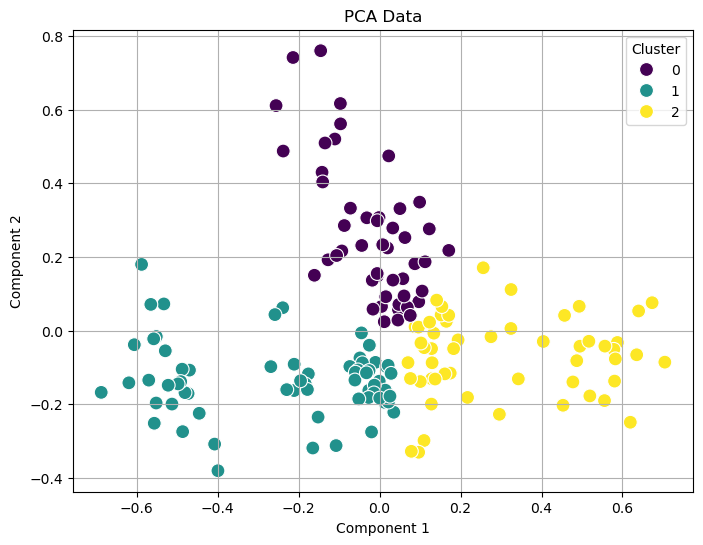

In [11]:
# Scatter plot for PCA results
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:,1], hue=kmeans_clusters, palette='viridis', s=100)
plt.title('PCA Data')
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.legend(title='Cluster')
plt.grid(True)


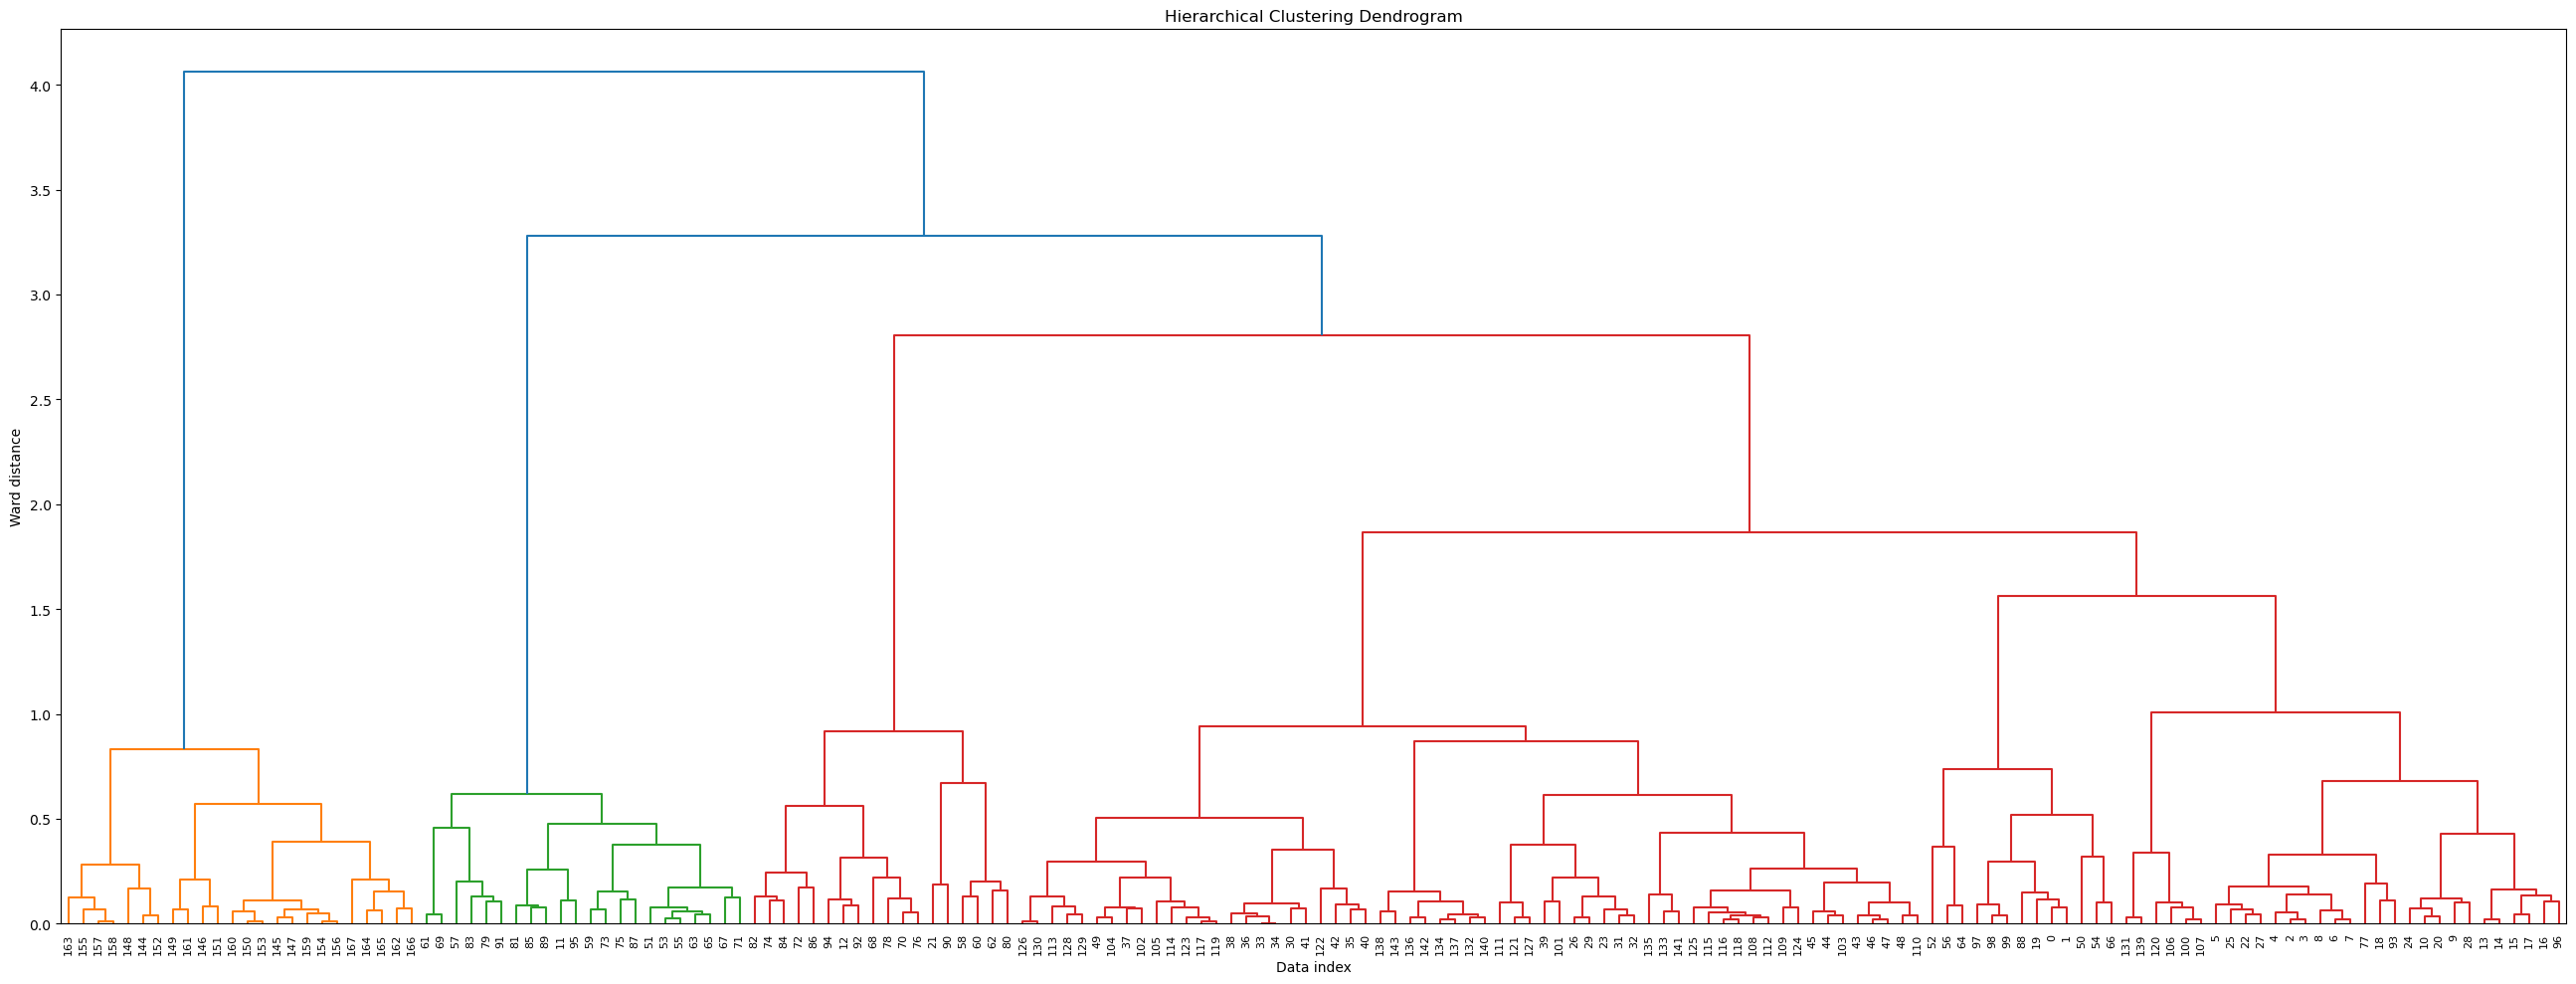

In [12]:
plt.figure(figsize=(26, 10))  # make it wider

dendrogram(
    linked,
    leaf_rotation=90,     # rotate labels
    leaf_font_size=8      # smaller text
)

plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Data index')
plt.ylabel('Ward distance')
plt.axhline(y=10, color='r', linestyle='--')

plt.tight_layout()
plt.show()


## Interpratation

In [13]:
# Cluster analysis

cluster_info = pd.DataFrame({
    'Cluster': kmeans_clusters,
    'Age': client_data['Edad'],
    'Income': client_data['Ingresos Anuales (k$)'],
    'Spent': client_data['Puntuación de Gasto (1-100)'],
    'Favorite_Category': client_data['Categoría de Producto Favorito']
})

# Means by cluster
for cluster in cluster_info['Cluster'].unique():

    cluster_data = cluster_info[
        cluster_info['Cluster'] == cluster
    ]

    print(f"\nCluster {cluster}:")

    print(f" - Age Mean: {cluster_data['Age'].mean():.2f}")
    print(f" - Income Mean: {cluster_data['Income'].mean():.2f}")
    print(f" - Spent Mean: {cluster_data['Spent'].mean():.2f}")

    print("\n Favorite categories:")

    print(
        cluster_data['Favorite_Category']
        .value_counts()
    )


Cluster 0:
 - Age Mean: 46.15
 - Income Mean: 40.67
 - Spent Mean: 34.42

 Favorite categories:
Favorite_Category
Home           21
Books          16
Electronics     6
Food            5
Name: count, dtype: int64

Cluster 2:
 - Age Mean: 28.57
 - Income Mean: 40.24
 - Spent Mean: 64.37

 Favorite categories:
Favorite_Category
Electronics    20
Food           19
Books          11
Home            4
Name: count, dtype: int64

Cluster 1:
 - Age Mean: 34.03
 - Income Mean: 77.86
 - Spent Mean: 28.83

 Favorite categories:
Favorite_Category
Home           17
Electronics    17
Food           16
Books          16
Name: count, dtype: int64


In [14]:
# ── ANOMALY EXPLAINER ──────────────────────────────────────────
# Reads the pipeline's run summary and asks GPT to explain
# any data quality issues in plain English.

anomaly_explanation = explain_anomalies(log_dir="./logs")

print("=" * 60)
print("DATA QUALITY REPORT (AI-Generated)")
print("=" * 60)
print(anomaly_explanation)

DATA QUALITY REPORT (AI-Generated)
During the recent data pipeline run, a total of 172 rows were processed, and 4 rows were dropped due to data quality issues. Specifically, one duplicate row was removed from the February customer data, while two outlier rows were removed from the March data. Additionally, one row in each of the February customer data files had missing values filled, but some values could not be interpreted as numbers, resulting in them being marked as 'NaN'. While these issues have been addressed, the analyst should remain vigilant, as the presence of non-numeric values may indicate deeper data problems.


In [15]:
# ── MARKETING STRATEGY GENERATOR ───────────────────────────────
# Sends each cluster's stats to GPT and gets back a persona name
# and 3 tailored campaign ideas per cluster.

marketing_results = generate_marketing_strategies(cluster_info)

print("\n" + "=" * 60)
print("AI-GENERATED MARKETING STRATEGIES")
print("=" * 60)

for cluster_id, data in marketing_results.items():
    strategy = data["strategy"]

    if "error" in strategy:
        print(f"\nCluster {cluster_id}: Error - {strategy['error']}")
        continue

    print(f"\nCLUSTER {cluster_id}: {strategy.get('persona_name', 'N/A')}")
    print(f"  {strategy.get('persona_description', '')}")
    print(f"  Avg Age: {data['stats']['age']:.1f}  |  "
          f"Income: ${data['stats']['income']:.0f}k  |  "
          f"Spending Score: {data['stats']['spending']:.1f}/100")
    print("  Campaigns:")

    for i, campaign in enumerate(strategy.get("campaigns", []), 1):
        print(f"    {i}. [{campaign.get('channel', '')}] {campaign.get('title', '')}")
        print(f"       {campaign.get('idea', '')}")

Generating strategy for Cluster 0...
Generating strategy for Cluster 1...
Generating strategy for Cluster 2...

AI-GENERATED MARKETING STRATEGIES

CLUSTER 0: Budget-Conscious Families
  These individuals are middle-aged, income-conscious consumers seeking affordable home and leisure products.
  Avg Age: 46.1  |  Income: $41k  |  Spending Score: 34.4/100
  Campaigns:
    1. [Email] Home Essentials Sale
       Promote a special sale on essential home goods to help families save while upgrading their living spaces.
    2. [Social Media] Book Club Discount
       Create a campaign encouraging book club members to purchase popular titles at a discount, fostering community and reading.
    3. [In-store] Tech for Less
       Host an in-store event showcasing affordable electronics that enhance daily life, with special promotions for attendees.

CLUSTER 1: Budget-Conscious Consumers
  These individuals are young professionals focused on balancing quality and affordability in their purchases.
 


# Key Business Insights & Conclusion
---

## What the Clustering Reveals

This analysis segmented customers into **three behaviorally distinct groups** using K-Means and Hierarchical Clustering on three features: Age, Annual Income, and Spending Score. Both methods converged on similar group boundaries, lending confidence to the segmentation.

The results surface a counterintuitive and commercially important finding: **the highest-income group is not the highest-spending group.**

| Cluster | Avg Age | Avg Income (k$) | Avg Spending Score | Top Category |
|---|---|---|---|---|
| Cluster 0 - Older Low Spenders | 46.15 | 40.67 | 34.42 | Home & Books |
| Cluster 1 - High-Income Selective Buyers | 34.03 | 77.86 | 28.83 | Evenly spread |
| Cluster 2 - Young High Spenders | 28.57 | 40.24 | 64.37 | Electronics & Food |

---

## Cluster Profiles

### Cluster 2: Young High Spenders (the most valuable segment)
Average age 28.6, average income $40k, yet they produce the highest spending score of 64.4 — nearly double Cluster 1 despite earning almost half as much. Their top categories are Electronics and Food, which are high-frequency, impulse-driven purchases. This group likely responds to social influence, convenience, and novelty over price sensitivity.

### Cluster 1: High-Income Selective Buyers (the underperforming segment)
The most affluent group (avg $77.9k income) but paradoxically the lowest spenders at 28.8. Their category preferences are evenly spread across all four categories, which suggests no strong product affinity or loyalty — they may be browsing broadly but converting rarely. This is the segment with the most untapped revenue potential.

### Cluster 0: Older Practical Shoppers (the retention segment)
Middle-aged customers (avg 46.2) with modest income and spending. Their strong lean toward Home and Books suggests habitual, needs-based purchasing rather than exploratory shopping. They are unlikely to be moved by trend-driven campaigns but may respond well to loyalty rewards and convenience features.

---

## The Core Business Signal

Income does not predict spending. Cluster 1 earns nearly twice as much as Cluster 2 but spends significantly less. This means:

- **Acquisition strategies** should not over-index on income as a targeting signal.
- **Engagement quality** — what motivates a customer to open an app, return to the site, or act on a notification — matters more than purchasing power.
- The highest ROI opportunity is **converting Cluster 1**: they have the income to spend more and simply are not. Understanding *why* (product-fit mismatch, low engagement, better alternatives) is the most valuable question this model raises.

---

## Strategic Takeaways

| Cluster | Priority Action | Expected Outcome |
|---|---|---|
| Cluster 2 - Young High Spenders | Double down on Electronics and Food promotions; use social and push channels; reward speed with flash offers | Protect and grow the highest-spending base |
| Cluster 1 - High-Income Selective | Investigate drop-off points; test premium product lines and personalized recommendations to find what converts them | Unlock significant latent revenue |
| Cluster 0 - Older Practical Shoppers | Loyalty programs, Home and Books bundles, convenience-focused messaging | Increase purchase frequency and reduce churn |

---

## Limitations of the Current Model

- The model uses only **3 features**, which limits segmentation granularity and may collapse meaningfully different sub-groups into a single cluster.
- K-Means assumes spherical clusters and is sensitive to outliers — the PCA scatter plot should be inspected to confirm separation is not driven by a few extreme values.
- The **Favorite Category** variable was used for interpretation but not included in the clustering itself, meaning the model did not optimize for product affinity — a notable gap given how strongly categories differ across clusters.
- Results reflect a static snapshot; spending behavior shifts seasonally and with economic conditions.

---

## Recommended Features to Enrich the Model

### 1. Purchase Frequency & Recency (RFM Signals)
**What it adds:** Distinguishes loyal repeat buyers from one-time purchasers. A customer spending $500 across 20 visits vs. once a year are very different targets.
**How to gather it:** Transaction logs from the CRM or e-commerce platform (order timestamps and amounts per customer ID).

### 2. Customer Lifetime Value (CLV)
**What it adds:** Shifts focus from current spending score to long-term revenue potential — critical for prioritizing Cluster 1 correctly.
**How to gather it:** Calculated from historical transaction data: average order value x purchase frequency x estimated customer lifespan.

### 3. Channel Preference (Online vs. In-Store, Device Type)
**What it adds:** Given Cluster 2's youth and Electronics affinity, channel data would likely reveal strong mobile/app usage — enabling more precise campaign placement.
**How to gather it:** Session logs from the website/app, point-of-sale flags, UTM tracking on marketing links.

### 4. Product Return Rate
**What it adds:** A high spending score means less if the customer returns frequently. Return patterns may also explain Cluster 1's low conversion.
**How to gather it:** Order management system records, linked to customer ID.

### 5. Geographic & Demographic Context
**What it adds:** Spending patterns vary by region and city size — clusters that appear homogeneous nationally may split meaningfully when geography is added.
**How to gather it:** Shipping addresses, registration data, or IP-based geolocation (with appropriate consent).

### 6. Customer Tenure (Account Age)
**What it adds:** Separates new customers (who may be in a high-spend onboarding phase) from established ones. Useful for churn prediction per cluster.
**How to gather it:** Account creation date from the user database.

### 7. Sentiment / Review Scores
**What it adds:** Captures satisfaction beyond transactional behavior. High-income low-spenders in Cluster 1 may have had negative past experiences suppressing their activity.
**How to gather it:** Post-purchase review ratings, NPS surveys, sentiment analysis on support tickets.

---

## Next Steps

1. **Investigate Cluster 1 drop-off** — run a funnel analysis to identify where high-income customers abandon the purchase journey. This is the single highest-value action from this analysis.
2. **Incorporate RFM features** as the next modeling priority — readily available and dramatically improve cluster interpretability.
3. **Include Favorite Category in the feature set** and re-run clustering; given the stark differences observed, it is likely to sharpen segmentation significantly.
4. **A/B test marketing strategies** per cluster to empirically validate the campaign recommendations above.
5. **Set a re-clustering schedule** (quarterly) since spending behavior shifts with seasons, economic conditions, and product catalog changes.
